In [16]:
# Import the libraries required to load the trained model,
# reproduce the modelling features and explain predictions.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap

In [17]:
# Load the verified synthetic dataset and the trained FairCredit model.

df = pd.read_csv("../data/faircredit_sa_dataset_verified.csv")

model = joblib.load("../models/faircredit_risk_model.pkl")
features = joblib.load("../models/faircredit_model_features.pkl")

In [18]:
# Recreate the same engineered financial ratios used during model training.
#
# The application and explanation pipeline must calculate these features
# exactly as they were calculated when the model was trained.

df["debt_to_income_ratio"] = (
    df["existing_debt_repayments"] /
    df["monthly_net_income"].clip(lower=1)
)

df["requested_credit_to_income_ratio"] = (
    df["requested_credit_amount"] /
    (df["monthly_gross_income"].clip(lower=1) * 12)
)

df["installment_to_income_ratio"] = (
    df["proposed_installment"] /
    df["monthly_net_income"].clip(lower=1)
)

df["expense_to_income_ratio"] = (
    df["living_expenses_used"] /
    df["monthly_net_income"].clip(lower=1)
)

df["savings_to_income_ratio"] = (
    df["savings_amount"] /
    df["monthly_net_income"].clip(lower=1)
)

df["arrears_to_income_ratio"] = (
    df["arrears_amount"] /
    df["monthly_net_income"].clip(lower=1)
)

X = df[features]

In [19]:
# The trained FairCredit pipeline contains both a StandardScaler and
# Logistic Regression model. SHAP should explain the actual regression
# model using the same scaled data it received during training.

scaler = model.named_steps["scaler"]
logistic_regression = model.named_steps["model"]

X_scaled = scaler.transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=features
)

In [20]:
# LinearExplainer is appropriate because the selected FairCredit model
# is Logistic Regression.
# SHAP values indicate how each feature pushes the model's prediction
# toward higher or lower estimated credit risk.

explainer = shap.LinearExplainer(
    logistic_regression,
    X_scaled_df
)

shap_values = explainer(X_scaled_df)

Background dataset has 10000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=10000 when initializing the masker.


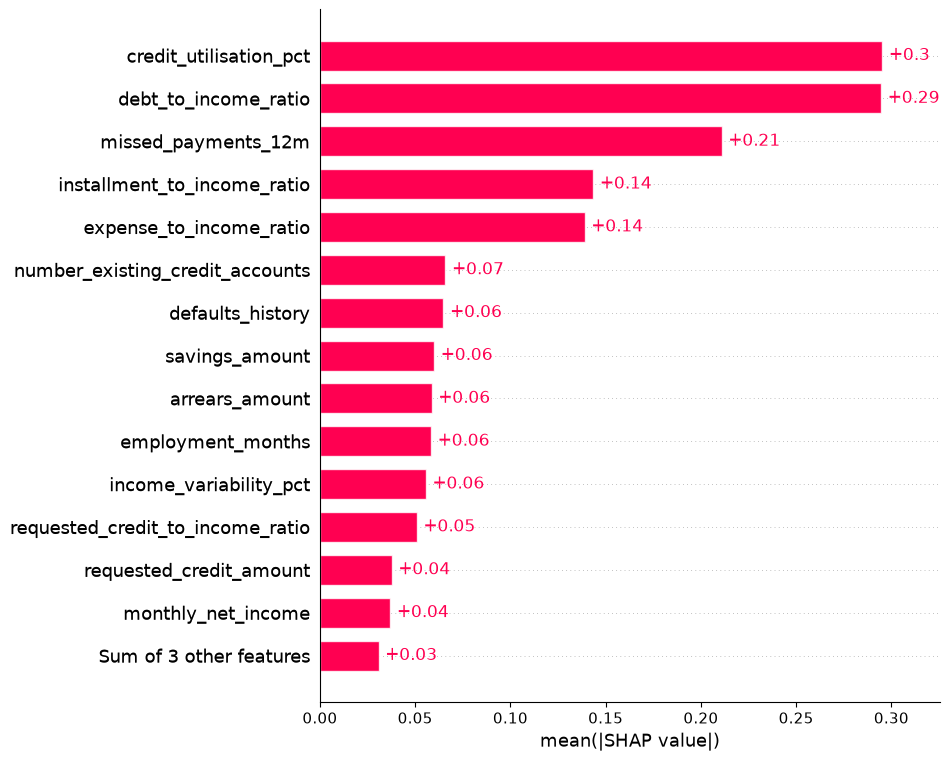

In [21]:
# Display the overall features with the greatest influence on model predictions.
# This does not imply causation. It only describes the behaviour learned by the model from the synthetic training dataset.

shap.plots.bar(
    shap_values,
    max_display=15
)

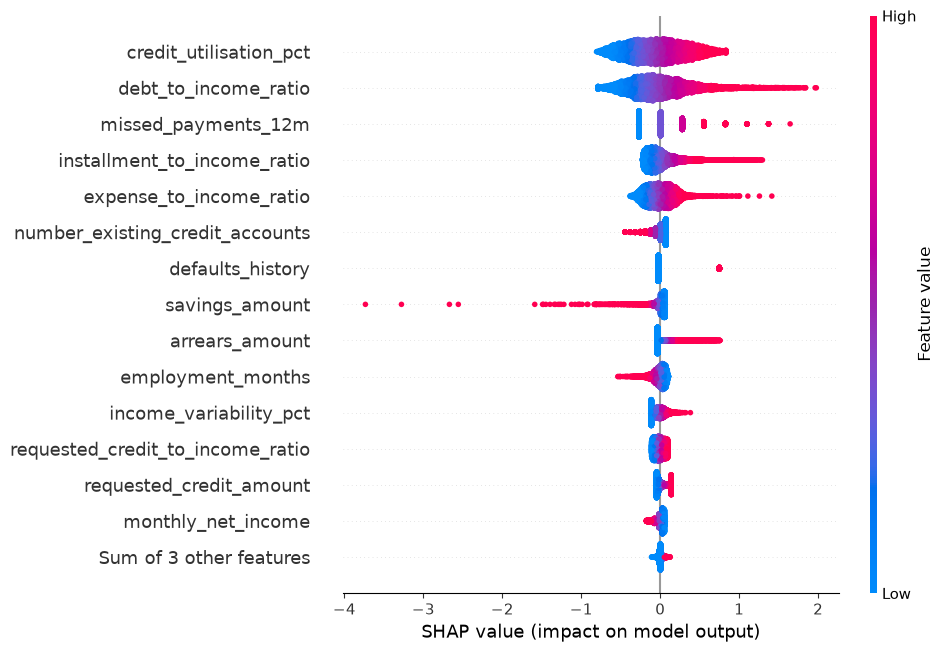

In [22]:
# The beeswarm plot shows both feature importance and the direction of
# each feature's contribution toward higher or lower estimated risk.

shap.plots.beeswarm(
    shap_values,
    max_display=15
)

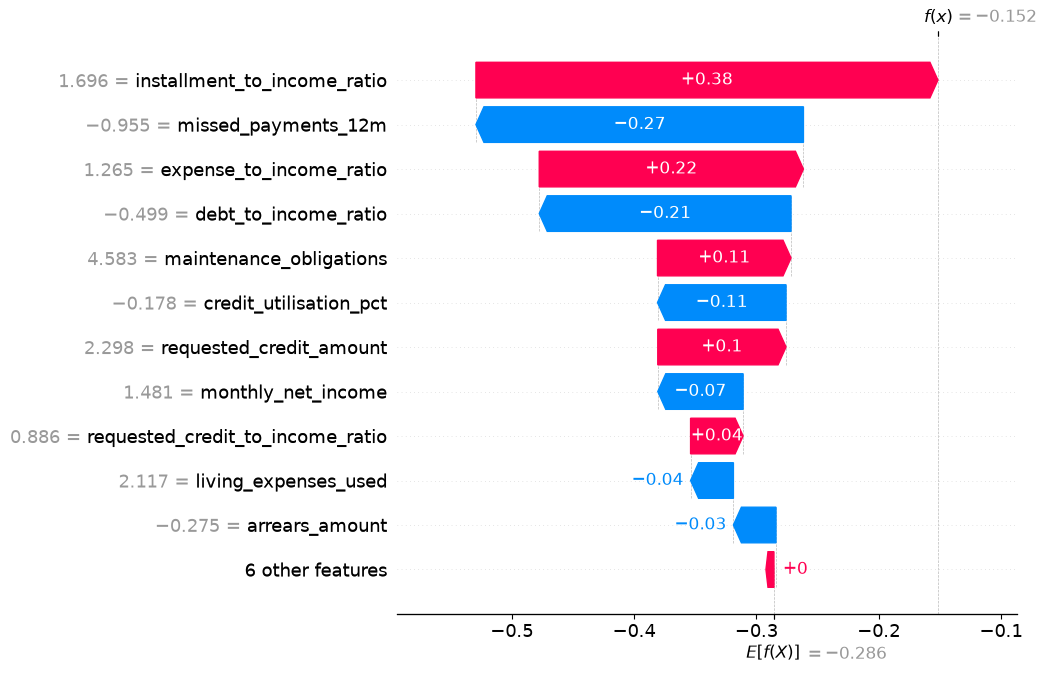

In [23]:
# Select one applicant as an example for an individual explanation.

applicant_index = 0

shap.plots.waterfall(
    shap_values[applicant_index],
    max_display=12
)

In [24]:
# Calculate the estimated higher-risk probability for the selected consumer.

applicant = X.iloc[[applicant_index]]

risk_probability = model.predict_proba(applicant)[0, 1]

readiness_score = round((1 - risk_probability) * 100)

print(f"Estimated risk probability: {risk_probability:.1%}")
print(f"FairCredit readiness score: {readiness_score}/100")

Estimated risk probability: 46.2%
FairCredit readiness score: 54/100


In [25]:
# Convert technical model feature names into labels that ordinary users can understand. These labels will later be reused in the FairCredit app.

friendly_feature_names = {
    "credit_utilisation_pct": "Credit utilisation",
    "debt_to_income_ratio": "Debt relative to income",
    "missed_payments_12m": "Missed payments",
    "expense_to_income_ratio": "Living expenses relative to income",
    "monthly_net_income": "Monthly net income",
    "installment_to_income_ratio": "New repayment relative to income",
    "requested_credit_to_income_ratio": "Requested credit relative to income",
    "proposed_installment": "Proposed monthly repayment",
    "statutory_deductions": "Statutory deductions",
    "defaults_history": "Previous default history",
    "number_existing_credit_accounts": "Existing credit accounts",
    "monthly_gross_income": "Monthly gross income",
    "employment_months": "Income/employment stability",
    "savings_to_income_ratio": "Savings relative to income",
    "existing_debt_repayments": "Existing debt repayments",
    "maintenance_obligations": "Other financial obligations",
    "living_expenses_used": "Necessary living expenses",
    "income_variability_pct": "Income variability",
    "arrears_amount": "Outstanding arrears",
    "savings_amount": "Savings"
}

In [26]:
# Extract the most influential factors for one consumer.
# Positive SHAP values push the model toward higher estimated risk.
# Negative SHAP values push the model toward lower estimated risk.
# The function returns model explanations rather than claiming that any feature directly caused a real-world lending outcome.

def explain_applicant(shap_values, applicant_index, top_n=5):

    applicant_shap = shap_values[applicant_index]

    explanation = pd.DataFrame({
        "Feature": applicant_shap.feature_names,
        "SHAP Value": applicant_shap.values
    })

    explanation["Absolute Impact"] = explanation["SHAP Value"].abs()

    explanation = explanation.sort_values(
        "Absolute Impact",
        ascending=False
    )

    explanation["Display Name"] = explanation["Feature"].map(
        friendly_feature_names
    ).fillna(explanation["Feature"])

    increasing_risk = explanation[
        explanation["SHAP Value"] > 0
    ].head(top_n)

    reducing_risk = explanation[
        explanation["SHAP Value"] < 0
    ].head(top_n)

    return increasing_risk, reducing_risk

In [27]:
# Retrieve the strongest factors pushing this consumer's estimated risk upward and downward.

risk_factors, positive_factors = explain_applicant(
    shap_values,
    applicant_index=0,
    top_n=5
)

print("FACTORS INCREASING ESTIMATED RISK")
display(
    risk_factors[
        ["Display Name", "SHAP Value"]
    ]
)

print("\nFACTORS REDUCING ESTIMATED RISK")
display(
    positive_factors[
        ["Display Name", "SHAP Value"]
    ]
)

FACTORS INCREASING ESTIMATED RISK


,Display Name,SHAP Value
15,New repayment relative to income,0.377738
16,Living expenses relative to income,0.216010
2,Other financial obligations,0.109165
3,requested_credit_amount,0.104872
14,Requested credit relative to income,0.042941



FACTORS REDUCING ESTIMATED RISK


,Display Name,SHAP Value
6,Missed payments,-0.267764
13,Debt relative to income,-0.205863
12,Credit utilisation,-0.105089
0,Monthly net income,-0.069769
1,Necessary living expenses,-0.035011


In [28]:
# Attach the consumer's original, human-readable values to the SHAP
# explanation. This avoids exposing the standardised values used internally by Logistic Regression.

def explain_applicant_with_values(
    shap_values,
    original_data,
    applicant_index,
    top_n=5
):

    applicant_shap = shap_values[applicant_index]

    explanation = pd.DataFrame({
        "Feature": applicant_shap.feature_names,
        "SHAP Value": applicant_shap.values
    })

    explanation["Actual Value"] = [
        original_data.iloc[applicant_index][feature]
        for feature in explanation["Feature"]
    ]

    explanation["Absolute Impact"] = (
        explanation["SHAP Value"].abs()
    )

    explanation["Display Name"] = (
        explanation["Feature"]
        .map(friendly_feature_names)
        .fillna(explanation["Feature"])
    )

    explanation = explanation.sort_values(
        "Absolute Impact",
        ascending=False
    )

    increasing_risk = explanation[
        explanation["SHAP Value"] > 0
    ].head(top_n)

    reducing_risk = explanation[
        explanation["SHAP Value"] < 0
    ].head(top_n)

    return increasing_risk, reducing_risk

In [29]:
risk_factors, positive_factors = explain_applicant_with_values(
    shap_values,
    X,
    applicant_index=0,
    top_n=3
)

print("Factors increasing estimated risk:")
display(
    risk_factors[
        ["Display Name", "Actual Value", "SHAP Value"]
    ]
)

print("Factors reducing estimated risk:")
display(
    positive_factors[
        ["Display Name", "Actual Value", "SHAP Value"]
    ]
)

Factors increasing estimated risk:


,Display Name,Actual Value,SHAP Value
15,New repayment relative to income,0.236038,0.377738
16,Living expenses relative to income,0.549180,0.216010
2,Other financial obligations,2694.830000,0.109165


Factors reducing estimated risk:


,Display Name,Actual Value,SHAP Value
6,Missed payments,0.000000,-0.267764
13,Debt relative to income,0.107025,-0.205863
12,Credit utilisation,43.400000,-0.105089
